In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, isfinite
from scipy.stats import t as t_dist, spearmanr, pearsonr, norm

In [9]:
# Pandas :: view ALL
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [11]:
# Pandas :: Default view
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
# Defines
def analyse_dataframe(df):
    nan_cnt = df.isnull().sum()
    nan_rto = df.isnull().mean()*100
    unique_vals_cnt = df.nunique()

    ana_result = pd.DataFrame({
        'NaN Counts' : nan_cnt
        , 'NaN Ratio (%)' : nan_rto
        , 'Unique Values' : unique_vals_cnt
    })
    return ana_result


In [4]:
## PRE
out = r"D:\JHAhn\files"

In [5]:
# dfA = pd.read_excel(os.path.join(out, 'Auto_ALPS_index_19-24_main.xlsx'))
dfA = pd.read_excel(os.path.join(out, '안재혁_8641_Auto_ALPS_index_19-24_main+CTI.xlsx'))
dfA['PID'] = (dfA['PID'].astype(str)
                        .str.strip()
                        .str.replace(r'\.0$', '', regex=True)
                        .str.replace(r'\D', '', regex=True)
                        .str.zfill(8))
dfA = dfA.drop(columns=['PDI']).set_index('PID')
dfA

,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,LT_ALL_Dyy_proj,...,LT_CTI_Assoc_Dyy,LT_CTI_Assoc_Dzz,LT_CTI-ALPS index,RT_CTI_Proj_Dxx,RT_CTI_Proj_Dyy,RT_CTI_Proj_Dzz,RT_CTI_Assoc_Dxx,RT_CTI_Assoc_Dyy,RT_CTI_Assoc_Dzz,RT_CTI-ALPS index
PID,,,,,,,,,,,,,,,,,,,,,
02459562,NL,0,82,1,F,6.0,27,0.0,0.745723,0.681610,...,0.472277,0.365113,1.109783,0.520848,0.521945,0.838614,0.467179,0.576006,0.492187,0.974257
00310282,AD,2,66,1,F,NaN,23,0.5,0.687428,0.615440,...,0.183024,0.106396,1.464138,0.065613,0.067988,0.281590,0.176224,0.300066,0.182062,0.967150
00454439,AD,2,74,0,M,NaN,13,2.0,0.884833,1.023749,...,0.660463,0.603218,1.030054,0.572164,0.576388,0.822231,0.644952,0.752475,0.651444,0.991272
00461257,SaMCI,1,74,1,F,12.0,27,0.5,0.688375,0.571691,...,0.237381,0.136555,1.267073,0.154561,0.157407,0.506764,0.192443,0.356904,0.196123,0.981540
00612238,AD,2,83,1,F,NaN,24,1.0,0.687521,0.567993,...,0.288539,0.223676,1.173859,0.304080,0.295770,0.657524,0.360456,0.467134,0.333783,1.055569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10412739,SaMCI,1,72,1,F,NaN,28,0.5,0.753935,0.504262,...,0.200644,0.137980,1.401680,0.060288,0.061287,0.217723,0.152784,0.181179,0.100257,1.318971
10474812,MaMCI,1,78,1,F,NaN,29,0.5,0.602834,0.559894,...,0.299302,0.205978,1.218601,0.095568,0.095638,0.362974,0.188456,0.319088,0.206177,0.941056
10482577,SaMCI,1,66,0,M,NaN,28,0.5,0.638415,0.664246,...,0.252498,0.184627,1.198815,0.128332,0.117998,0.345852,0.233705,0.350583,0.250176,0.983328


In [7]:
for column in dfA.columns:
    print(f"Col name: {column}")
    print(f"Data type: {dfA[column].dtype}")
    print("Unique values:")
    print(dfA[column].unique())
    print("-"*50)

Col name: DDX
Data type: object
Unique values:
['NL' 'AD' 'SaMCI' 'MaMCI']
--------------------------------------------------
Col name: Group
Data type: int64
Unique values:
[0 2 1]
--------------------------------------------------
Col name: Age
Data type: int64
Unique values:
[82 66 74 83 69 77 76 87 96 72 73 62 89 78 63 79 85 80 67 65 86 61 81 71
 58 68 60 75 70 64]
--------------------------------------------------
Col name: Sex_01
Data type: int64
Unique values:
[1 0]
--------------------------------------------------
Col name: Sex
Data type: object
Unique values:
['F' 'M']
--------------------------------------------------
Col name: Education (Year)
Data type: float64
Unique values:
[ 6. nan 12. 16. 18. 19.  0.  4.  8.  9. 14. 13. 10.  7.  2.  5.  3.]
--------------------------------------------------
Col name: MMSE
Data type: int64
Unique values:
[27 23 13 24 26 25 22 30  9 29 10 19 16 28 20]
--------------------------------------------------
Col name: CDR
Data type: float64
Uni

In [10]:
analyse_dataframe(dfA)

,NaN Counts,NaN Ratio (%),Unique Values
DDX,0,0.000000,4
Group,0,0.000000,3
Age,0,0.000000,30
Sex_01,0,0.000000,2
Sex,0,0.000000,2
Education (Year),33,32.352941,16
MMSE,0,0.000000,15
CDR,0,0.000000,4
LT_ALL_Dxx_proj,0,0.000000,101
LT_ALL_Dyy_proj,0,0.000000,101


In [14]:
def pearson_corr_table(df: pd.DataFrame, x: str,
                       y_cols=None, decimals: int = 3,
                       p_floor: float = 0.001):
    """
    MedCalc와 유사한 보고 형식:
      - Pearson's correlation coefficient (r)
      - two-tailed p-value
      - 95% CI for r (Fisher z)
    """
    if y_cols is None:
        y_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != x]

    out = []
    for y in y_cols:
        sub = df[[x, y]].apply(pd.to_numeric, errors='coerce').dropna()
        n = len(sub)

        # 표본/상수열 체크
        if n <= 3 or sub[x].nunique() <= 1 or sub[y].nunique() <= 1:
            out.append({
                'Variables': y,
                "Pearson's correlation coefficient (r)": np.nan,
                'p-value': np.nan,
                '95% Confidence Interval for r': np.nan
            })
            continue

        # r & p (two-tailed)
        r, p = pearsonr(sub[x], sub[y])

        # 95% CI (Fisher z)
        r_ = float(max(min(r, 0.999999999), -0.999999999))
        z  = 0.5 * np.log((1 + r_) / (1 - r_))
        se = 1.0 / np.sqrt(n - 3)
        zc = norm.ppf(0.975)
        lo = np.tanh(z - zc * se)
        hi = np.tanh(z + zc * se)

        # formatting
        r_out = f"{r:.{decimals}f}" if np.isfinite(r) else np.nan
        if np.isfinite(p):
            p_out = f"≤ {p_floor:.3f}" if p < p_floor else f"{p:.{decimals}f}"
        else:
            p_out = np.nan
        ci_out = (f"{lo:.{decimals}f} to {hi:.{decimals}f}"
                  if np.isfinite(lo) and np.isfinite(hi) else np.nan)

        out.append({
            'Variables': y,
            "Pearson's correlation coefficient (r)": r_out,
            'p-value': p_out,
            '95% Confidence Interval for r': ci_out
        })

    return pd.DataFrame(out)

In [23]:
# CTI: LT_CTI_Proj_Dxx / RT_CTI_Assoc_Dyy / ...
pat_cti = re.compile(r'^(LT|RT)_CTI_(Proj|Assoc)_(Dxx|Dyy|Dzz)$')

# DTI: LT_ALL_Dxx_proj / LT_b800_Dyy_assoc / RT_b2000_Dzz_proj ...
pat_dti = re.compile(r'^(LT|RT)_(ALL|b800|b2000)_(Dxx|Dyy|Dzz)_(proj|assoc)$', re.I)

def parse_cti(col):
    m = pat_cti.match(col)
    if not m:
        return None
    side, kind, comp = m.groups()                 # kind: Proj/Assoc
    return side, kind.lower(), comp               # ('LT','proj','Dxx')

def parse_dti(col):
    m = pat_dti.match(col)
    if not m:
        return None
    side, band, comp, kind = m.groups()           # kind: proj/assoc
    return side, band, comp, kind.lower()         # ('LT','ALL','Dxx','proj')

# ---------- 2) r,p 계산 + 포맷 ----------
def _pearson_rp(df, a, b):
    sub = df[[a, b]].apply(pd.to_numeric, errors='coerce').dropna()
    if sub.shape[0] <= 3 or sub[a].nunique() <= 1 or sub[b].nunique() <= 1:
        return np.nan, np.nan
    r, p = pearsonr(sub[a], sub[b])
    return float(r), float(p)

def _fmt_rp(r, p, decimals=3, p_floor=0.001):
    if not (np.isfinite(r) and np.isfinite(p)):
        return ""
    r_txt = f"{r:.{decimals}f}"
    p_txt = f"< {p_floor:.3f}" if p < p_floor else f"= {p:.{decimals}f}"
    # 예: r=-0.091, p=0.363  /  r=0.355, p<0.001
    return f"r={r_txt}, p{p_txt}"

# ---------- 3) 교차컴포넌트까지 모두 채우는 표 생성 ----------
def build_cti_dti_cross_table(df):
    # 숫자형 강제
    df = df.copy()
    df = df.apply(pd.to_numeric, errors='ignore')

    # 후보 칼럼 수집
    cti_cols = [c for c in df.columns if pat_cti.match(c)]
    dti_cols = [c for c in df.columns if pat_dti.match(c)]

    # CTI 타겟(열) 12개 정의: (표의 열 순서)
    cti_targets = []
    for side in ('LT', 'RT'):
        for kind in ('Proj', 'Assoc'):
            for comp in ('Dxx', 'Dyy', 'Dzz'):
                cti_targets.append((side, kind, comp))
    # 열 라벨
    col_labels = []
    for side in ('LT', 'RT'):
        for kind in ('Projection', 'Association'):         # 사람이 읽는 라벨
            for comp in ('Dxx', 'Dyy', 'Dzz'):
                col_labels.append(f"{side} {kind} {comp}")

    # DTI 행(기준 변수) 루프: Side × Type × Band × Component
    rows = []
    for side in ('LT', 'RT'):
        for kind in ('proj', 'assoc'):
            for band in ('ALL', 'b800', 'b2000'):
                for comp in ('Dxx', 'Dyy', 'Dzz'):
                    # 기준 DTI 칼럼명 찾기
                    y0 = f"{side}_{band}_{comp}_{kind}"
                    if y0 not in df.columns:
                        # 해당 조합이 없으면 비워둔 행만 추가
                        row = {
                            'Side': side,
                            'DTI Type': 'Projection' if kind=='proj' else 'Association',
                            'Band': 'ALL' if band=='ALL' else ('b=800' if band=='b800' else 'b=2000'),
                            'Component': comp
                        }
                        for lbl in col_labels:
                            row[lbl] = ""
                        rows.append(row)
                        continue

                    # 이 행의 기본 메타
                    row = {
                        'Side': side,
                        'DTI Type': 'Projection' if kind=='proj' else 'Association',
                        'Band': 'ALL' if band=='ALL' else ('b=800' if band=='b800' else 'b=2000'),
                        'Component': comp
                    }

                    # 12개의 CTI 타겟과의 상관식 채우기
                    for (cti_side, cti_kind, cti_comp), lbl in zip(cti_targets, col_labels):
                        x0 = f"{cti_side}_CTI_{cti_kind}_{cti_comp}"   # 예: LT_CTI_Proj_Dxx
                        if x0 not in df.columns:
                            row[lbl] = ""
                            continue
                        r, p = _pearson_rp(df, x0, y0)
                        row[lbl] = _fmt_rp(r, p, decimals=3, p_floor=0.001)

                    rows.append(row)

    out = pd.DataFrame(rows)

    # 보기 좋은 정렬
    type_cat = pd.Categorical(out['DTI Type'], categories=['Projection','Association'], ordered=True)
    band_cat = pd.Categorical(out['Band'], categories=['ALL','b=800','b=2000'], ordered=True)
    comp_cat = pd.Categorical(out['Component'], categories=['Dxx','Dyy','Dzz'], ordered=True)
    out = (out
           .assign(**{'DTI Type': type_cat, 'Band': band_cat, 'Component': comp_cat})
           .sort_values(['Side','DTI Type','Band','Component'])
           .reset_index(drop=True))

    return out

In [24]:
corr_table = build_cti_dti_cross_table(dfA)
corr_table

,Side,DTI Type,Band,Component,LT Projection Dxx,LT Projection Dyy,LT Projection Dzz,LT Association Dxx,LT Association Dyy,LT Association Dzz,RT Projection Dxx,RT Projection Dyy,RT Projection Dzz,RT Association Dxx,RT Association Dyy,RT Association Dzz
0,LT,Projection,ALL,Dxx,"r=-0.091, p= 0.363","r=-0.082, p= 0.410","r=-0.088, p= 0.378","r=-0.049, p= 0.621","r=-0.080, p= 0.425","r=-0.058, p= 0.565","r=-0.085, p= 0.398","r=-0.083, p= 0.409","r=-0.082, p= 0.411","r=-0.103, p= 0.305","r=-0.090, p= 0.371","r=-0.102, p= 0.306"
1,LT,Projection,ALL,Dyy,"r=-0.086, p= 0.387","r=-0.079, p= 0.432","r=-0.085, p= 0.396","r=-0.048, p= 0.633","r=-0.075, p= 0.453","r=-0.055, p= 0.586","r=-0.080, p= 0.423","r=-0.078, p= 0.434","r=-0.079, p= 0.433","r=-0.099, p= 0.322","r=-0.084, p= 0.400","r=-0.098, p= 0.326"
2,LT,Projection,ALL,Dzz,"r=-0.094, p= 0.347","r=-0.085, p= 0.397","r=-0.089, p= 0.376","r=-0.048, p= 0.630","r=-0.077, p= 0.439","r=-0.056, p= 0.578","r=-0.085, p= 0.397","r=-0.083, p= 0.410","r=-0.081, p= 0.420","r=-0.102, p= 0.308","r=-0.088, p= 0.381","r=-0.100, p= 0.318"
3,LT,Projection,b=800,Dxx,"r=0.167, p= 0.094","r=0.140, p= 0.161","r=0.125, p= 0.209","r=0.070, p= 0.483","r=-0.099, p= 0.321","r=0.011, p= 0.909","r=0.016, p= 0.874","r=0.001, p= 0.992","r=-0.033, p= 0.743","r=0.023, p= 0.820","r=-0.008, p= 0.938","r=-0.026, p= 0.797"
4,LT,Projection,b=800,Dyy,"r=0.430, p< 0.001","r=0.366, p< 0.001","r=0.320, p= 0.001","r=0.157, p= 0.115","r=0.253, p= 0.010","r=0.218, p= 0.027","r=0.321, p= 0.001","r=0.298, p= 0.002","r=0.235, p= 0.018","r=0.261, p= 0.008","r=0.364, p< 0.001","r=0.257, p= 0.009"
5,LT,Projection,b=800,Dzz,"r=-0.100, p= 0.319","r=-0.069, p= 0.491","r=0.053, p= 0.597","r=0.133, p= 0.182","r=0.096, p= 0.338","r=0.141, p= 0.158","r=0.004, p= 0.971","r=0.011, p= 0.912","r=0.085, p= 0.395","r=0.051, p= 0.614","r=0.127, p= 0.203","r=0.150, p= 0.131"
6,LT,Projection,b=2000,Dxx,"r=0.355, p< 0.001","r=0.314, p= 0.001","r=0.276, p= 0.005","r=0.188, p= 0.058","r=0.033, p= 0.746","r=0.120, p= 0.229","r=0.234, p= 0.018","r=0.211, p= 0.033","r=0.156, p= 0.117","r=0.132, p= 0.186","r=0.133, p= 0.183","r=0.064, p= 0.524"
7,LT,Projection,b=2000,Dyy,"r=0.557, p< 0.001","r=0.489, p< 0.001","r=0.400, p< 0.001","r=0.207, p= 0.037","r=0.336, p< 0.001","r=0.279, p= 0.005","r=0.478, p< 0.001","r=0.456, p< 0.001","r=0.355, p< 0.001","r=0.319, p= 0.001","r=0.442, p< 0.001","r=0.306, p= 0.002"
8,LT,Projection,b=2000,Dzz,"r=0.090, p= 0.370","r=0.148, p= 0.139","r=0.224, p= 0.024","r=0.318, p= 0.001","r=0.330, p< 0.001","r=0.371, p< 0.001","r=0.162, p= 0.103","r=0.181, p= 0.068","r=0.240, p= 0.015","r=0.196, p= 0.049","r=0.267, p= 0.007","r=0.298, p= 0.002"
9,LT,Association,ALL,Dxx,"r=-0.091, p= 0.362","r=-0.082, p= 0.410","r=-0.088, p= 0.379","r=-0.047, p= 0.641","r=-0.079, p= 0.433","r=-0.056, p= 0.579","r=-0.084, p= 0.402","r=-0.082, p= 0.413","r=-0.081, p= 0.416","r=-0.101, p= 0.312","r=-0.088, p= 0.380","r=-0.100, p= 0.315"


In [25]:
# corr_table.to_excel(r'...\CTI_DTI_cross_components.xlsx', index=False)  # 저장 옵션
corr_table.to_excel(os.path.join(out, 'compALPS_Pearson_CorrResults_M03.xlsx'))

In [5]:
def spearman_rank_table(df: pd.DataFrame, x: str
                        , y_cols=None, decimals: int = 3
                        , p_floor: float = 0.001):
    if y_cols is None:
        y_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != x]

    out = []
    for y in y_cols:
        sub = df[[x, y]].apply(pd.to_numeric, errors='coerce').dropna()
        n = len(sub)

        # 자료 부족/상수열 방지
        if n <= 3 or sub[x].nunique() <= 1 or sub[y].nunique() <= 1:
            out.append({
                'Variables': y,
                "Spearman's coefficient of rank correlation (rho)": np.nan,
                'p-value': np.nan,
                '95% Confidence Interval for rho': np.nan
            })
            continue

        rho, p = spearmanr(sub[x], sub[y])

        # Fisher z 95% CI (rho ±1에 근접 시 클램프)
        r_ = float(max(min(rho, 0.999999999), -0.999999999))
        z  = 0.5 * np.log((1 + r_) / (1 - r_))
        se = 1.0 / np.sqrt(n - 3)
        zc = norm.ppf(0.975)  # 95% CI
        lo = np.tanh(z - zc * se)
        hi = np.tanh(z + zc * se)

        # formatting
        rho_out = f"{rho:.{decimals}f}" if np.isfinite(rho) else np.nan
        if np.isfinite(p):
            p_out = f"≤ {p_floor:.3f}" if p < p_floor else f"{p:.{decimals}f}"
        else:
            p_out = np.nan
        ci_out = (f"{lo:.{decimals}f} to {hi:.{decimals}f}"
                  if np.isfinite(lo) and np.isfinite(hi) else np.nan)

        out.append({
            'Variables': y,
            "Spearman's coefficient of rank correlation (rho)": rho_out,
            'p-value': p_out,
            '95% Confidence Interval for rho': ci_out
        })

    return pd.DataFrame(out)

In [6]:
Rank_res = spearman_rank_table(dfA, x='Age')
# res2 = spearman_rank_table(dfA, x='Age', y_cols=['MMSE','CDR','LT_ALL_Dxx_proj'])
Rank_res

,Variables,Spearman's coefficient of rank correlation (rho),p-value,95% Confidence Interval for rho
0,Group,0.279,0.004,0.090 to 0.449
1,Sex_01,0.000,1.000,-0.194 to 0.194
2,MMSE,-0.358,≤ 0.001,-0.516 to -0.176
3,CDR,0.325,≤ 0.001,0.139 to 0.489
4,LT_ALL_Dxx_proj,-0.049,0.622,-0.242 to 0.147
...,...,...,...,...
126,R_RT_HippoEC-HippoVol,0.512,≤ 0.001,0.352 to 0.642
127,R_LT_InsulaHFC-InsulaVol,0.530,≤ 0.001,0.374 to 0.657
128,R_RT_InsulaHFC-InsulaVol,0.532,≤ 0.001,0.376 to 0.658
129,R_LT_InsulaEC-InsulaVol,0.523,≤ 0.001,0.366 to 0.651


In [5]:
def partial_corr_table(df: pd.DataFrame, x: str, covariates, y_cols=None, decimals: int = 3):
    if covariates is None:
        covariates = []
    elif isinstance(covariates, str):
        covariates = [covariates]

    exclude = set([x] + covariates)

    if y_cols is None:
        y_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

    out = []
    for y in y_cols:
        sub = df[[x, y] + covariates].copy()

        sub[x] = pd.to_numeric(sub[x], errors='coerce')
        sub[y] = pd.to_numeric(sub[y], errors='coerce')
        for c in covariates:
            sub[c] = pd.to_numeric(sub[c], errors='coerce')

        sub = sub.dropna()
        n = len(sub)
        k = len(covariates)
        if n <= k + 2:
            out.append({'Variables': y, 'Correlation coefficient (r)': np.nan, 'p-value': np.nan})
            continue

        X = sub[x].to_numpy()
        Y = sub[y].to_numpy()
        Z = sub[covariates].to_numpy() if k else np.empty((n, 0))

        Z1 = np.column_stack([np.ones(n), Z]) if k else np.ones((n, 1))

        bx, *_ = np.linalg.lstsq(Z1, X, rcond=None)
        by, *_ = np.linalg.lstsq(Z1, Y, rcond=None)
        rx = X - Z1 @ bx
        ry = Y - Z1 @ by

        sx = rx.std(ddof=1); sy = ry.std(ddof=1)
        if sx == 0 or sy == 0 or not np.isfinite(sx) or not np.isfinite(sy):
            r = np.nan; p = np.nan
        else:
            r = float(np.corrcoef(rx, ry)[0, 1])
            dfree = n - k - 2
            r_ = max(min(r, 0.999999999), -0.999999999)
            t_stat = r_ * sqrt(dfree / (1 - r_**2))
            p = 2 * t_dist.sf(abs(t_stat), dfree)

        # Edit p-value format
        if isfinite(p):
            p_out = '≤ 0.001' if p < 0.001 else f"{p:.{decimals}f}"
        else:
            p_out = np.nan

        out.append({
            'Variables': y,
            'Correlation coefficient (r)': (round(r, decimals) if isfinite(r) else np.nan),
            'p-value': p_out
        })

    return pd.DataFrame(out)

In [8]:
# if Coveriate_col: Age
Partial_res = partial_corr_table(dfA, x='MMSE',
                         covariates=['Age'])

# Col_order tuning
# def sort_by_list(df, col, order_list, inplace=False):
#     key = df[col].map({v:i for i, v in enumerate(order_list)})
#     key = key.fillna(len(order_list))  # 리스트에 없는 값은 뒤로
#     out = df.assign(_k=key).sort_values('_k').drop(columns='_k')
#     if inplace:
#         df.drop(df.index, inplace=True)
#         df[:] = out.values
#         df.columns = out.columns
#         return None
#     return out
# order_vars = ['Age','Sex_01','Education (Year)','MMSE','CDR']
# res = sort_by_list(res, 'Variables', order_vars)
Partial_res

,Variables,Correlation coefficient (r),p-value
0,Group,-0.700,≤ 0.001
1,Sex_01,-0.011,0.912
2,CDR,-0.752,≤ 0.001
3,LT_ALL_Dxx_proj,0.016,0.870
4,LT_ALL_Dyy_proj,0.014,0.892
...,...,...,...
125,R_RT_HippoEC-HippoVol,-0.468,≤ 0.001
126,R_LT_InsulaHFC-InsulaVol,-0.406,≤ 0.001
127,R_RT_InsulaHFC-InsulaVol,-0.442,≤ 0.001
128,R_LT_InsulaEC-InsulaVol,-0.432,≤ 0.001


In [24]:
print(Rank_res, Partial_res)

                    Variables  \
0                       Group   
1                      Sex_01   
2                        MMSE   
3                         CDR   
4             LT_ALL_Dxx_proj   
..                        ...   
126     R_RT_HippoEC-HippoVol   
127  R_LT_InsulaHFC-InsulaVol   
128  R_RT_InsulaHFC-InsulaVol   
129   R_LT_InsulaEC-InsulaVol   
130   R_RT_InsulaEC-InsulaVol   

    Spearman's coefficient of rank correlation (rho)  p-value  \
0                                              0.279    0.004   
1                                              0.000    1.000   
2                                             -0.358  ≤ 0.001   
3                                              0.325  ≤ 0.001   
4                                             -0.049    0.622   
..                                               ...      ...   
126                                            0.512  ≤ 0.001   
127                                            0.530  ≤ 0.001   
128               

In [25]:
analyse_dataframe(dfA)
dfA

,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,LT_ALL_Dyy_proj,...,R_LT_insulaIC-HippoVol,R_RT_insulaIC-HippoVol,R_LT_HippoHFC-HippoVol,R_RT_HippoHFC-HippoVol,R_LT_HippoEC-HippoVol,R_RT_HippoEC-HippoVol,R_LT_InsulaHFC-InsulaVol,R_RT_InsulaHFC-InsulaVol,R_LT_InsulaEC-InsulaVol,R_RT_InsulaEC-InsulaVol
PID,,,,,,,,,,,,,,,,,,,,,
09463703,NL,0,74,0,M,18,29,0.0,0.776002,0.681788,...,0.348935,0.186446,2.404717,2.357931,1.717007,1.462156,1.223849,1.358577,1.010236,1.238754
08787368,NL,0,81,0,M,NaN,30,0.5,0.726724,0.886689,...,0.566516,0.363421,3.693273,4.055510,2.459454,2.541135,1.697680,1.735608,1.387783,1.555366
00145616,NL,0,70,1,F,16,30,0.0,0.853582,0.731372,...,0.433419,0.246285,2.452219,2.507971,1.594022,1.465982,0.971133,0.949739,0.798664,0.882029
02716077,NL,0,62,1,F,12,30,0.0,0.721595,0.654347,...,0.268350,0.207276,1.356863,2.057252,0.943260,1.149465,0.942765,0.970335,0.793535,0.881031
00469852,NL,0,72,0,M,16,28,0.0,0.648850,0.534350,...,0.388599,0.188881,2.162681,2.192102,1.825298,1.410017,1.178321,1.125617,0.911986,1.027800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
04717899,AD,2,60,0,M,14,24,1.0,0.704174,0.654193,...,0.688831,0.380781,4.662370,5.653312,3.555952,3.471790,2.188951,2.321183,1.817155,2.136617
02933875,AD,2,73,1,F,10,20,1.0,0.558741,0.604754,...,0.865564,0.332676,5.801521,4.953726,3.842815,3.325906,2.493253,2.683736,2.034330,2.376780
08542934,AD,2,81,1,F,7,20,1.0,0.558187,0.481649,...,0.622930,0.339742,3.113874,4.094166,2.786492,2.584707,1.932355,2.194530,1.604224,2.067276


In [13]:
## Correlations : ALPS & Conductivity

prefixes = ('HFC_', 'EC_', 'IC_', 'Age')
dfA1 = dfA.loc[:, [c for c in dfA.columns
                   if c.startswith(prefixes) or c.endswith('_ALPS index')]].copy()
dfA1

dfA2 = dfA.loc[:, [c for c in dfA.columns
                   if c.startswith(prefixes) or c.endswith('_ALPS index')]].copy()

,Age,LT_ALL_ALPS index,LT_b800_ALPS index,LT_b2000_ALPS index,RT_ALL_ALPS index,RT_b800_ALPS index,RT_b2000_ALPS index,HFC_LT_Amygdala,IC_LT_Amygdala,EC_LT_Amygdala,...,EC_RT_ParaHippocampus,HFC_RT_Thalamus,IC_RT_Thalamus,EC_RT_Thalamus,HFC_Whole_CC,IC_Whole_CC,EC_Whole_CC,HFC_Whole_Precuneus,IC_Whole_Precuneus,EC_Whole_Precuneus
PID,,,,,,,,,,,,,,,,,,,,,
09463703,74,1.272595,1.273617,1.327638,1.221257,1.219284,1.248897,0.576491,0.077111,0.466634,...,0.508526,0.863352,0.208503,0.654738,0.545173,0.151938,0.393254,0.678900,0.106224,0.569961
08787368,81,0.981989,0.980882,1.059175,1.035988,1.039021,1.110062,0.714089,0.093261,0.555673,...,0.447529,0.893360,0.172644,0.720655,0.583949,0.133841,0.450196,0.670014,0.110448,0.559206
00145616,70,1.230459,1.231623,1.185134,1.284944,1.285058,1.264723,0.532039,0.067141,0.496195,...,0.569473,0.826935,0.271682,0.555182,0.596481,0.212770,0.383751,0.628513,0.125133,0.503758
02716077,62,1.320335,1.325073,1.297953,1.555371,1.558936,1.564507,0.601685,0.114156,0.484033,...,0.489838,0.761443,0.233806,0.527660,0.482623,0.188198,0.294517,0.592590,0.139421,0.453941
00469852,72,1.364659,1.371532,1.321743,1.455350,1.461470,1.410687,0.506264,0.078504,0.393827,...,0.544412,0.850338,0.298828,0.551536,0.560023,0.178677,0.381515,0.707167,0.123957,0.582434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
04717899,60,1.164967,1.163750,1.107367,1.162248,1.165457,1.096130,0.623358,0.110868,0.570015,...,0.609766,0.938087,0.328847,0.609250,0.549789,0.098695,0.451263,0.697085,0.133887,0.564706
02933875,73,1.101484,1.102740,1.059014,1.139542,1.145148,1.095845,0.679944,0.102469,0.703749,...,0.660291,1.098645,0.369174,0.729657,0.591906,0.103356,0.488582,0.671573,0.118942,0.558888
08542934,81,1.341126,1.347343,1.249504,1.514043,1.523020,1.348642,0.619988,0.085374,0.491973,...,0.570976,1.067965,0.297566,0.770302,0.634396,0.160551,0.473912,0.711377,0.125849,0.581742


In [14]:
analyse_dataframe(dfA1)

,NaN Counts,NaN Ratio (%),Unique Values
Age,0,0.0,30
LT_ALL_ALPS index,0,0.0,101
LT_b800_ALPS index,0,0.0,101
LT_b2000_ALPS index,0,0.0,101
RT_ALL_ALPS index,0,0.0,101
RT_b800_ALPS index,0,0.0,101
RT_b2000_ALPS index,0,0.0,101
HFC_LT_Amygdala,0,0.0,101
IC_LT_Amygdala,0,0.0,101
EC_LT_Amygdala,0,0.0,101


In [17]:
ALPS_cols = [
    'LT_ALL_ALPS index', 'LT_b800_ALPS index', 'LT_b2000_ALPS index',
    'RT_ALL_ALPS index', 'RT_b800_ALPS index', 'RT_b2000_ALPS index'
]

alps_exist = [c for c in ALPS_cols if c in dfA1.columns]
alps_R = [c for c in alps_exist if c.startswith('RT_')]
alps_L = [c for c in alps_exist if c.startswith('LT_')]
dfA1R = dfA1[['Age'] + alps_R + [c for c in dfA1.columns if ('RT_' in c and c not in alps_R)]].copy()
dfA1L = dfA1[['Age'] + alps_L + [c for c in dfA1.columns if ('LT_' in c and c not in alps_L)]].copy()

# confirm Duplicated cols
overlap = set(alps_R) & set(alps_L)
if overlap:
    print('!!!! Cols in RT_/LT_ both datasets:', sorted(overlap))

In [18]:
analyse_dataframe(dfA1R)

,NaN Counts,NaN Ratio (%),Unique Values
Age,0,0.0,30
RT_ALL_ALPS index,0,0.0,101
RT_b800_ALPS index,0,0.0,101
RT_b2000_ALPS index,0,0.0,101
HFC_RT_Amygdala,0,0.0,101
IC_RT_Amygdala,0,0.0,101
EC_RT_Amygdala,0,0.0,101
HFC_RT_Hippocampus,0,0.0,101
IC_RT_Hippocampus,0,0.0,101
EC_RT_Hippocampus,0,0.0,101


In [19]:
analyse_dataframe(dfA1L)

,NaN Counts,NaN Ratio (%),Unique Values
Age,0,0.0,30
LT_ALL_ALPS index,0,0.0,101
LT_b800_ALPS index,0,0.0,101
LT_b2000_ALPS index,0,0.0,101
HFC_LT_Amygdala,0,0.0,101
IC_LT_Amygdala,0,0.0,101
EC_LT_Amygdala,0,0.0,101
HFC_LT_Hippocampus,0,0.0,101
IC_LT_Hippocampus,0,0.0,101
EC_LT_Hippocampus,0,0.0,101


In [65]:
## + another partial corr : ALPS

In [20]:
# LT_ALL_ALPS_index
# LT_b800_ALPS_index
# LT_b2000_ALPS_index
# RT_ALL_ALPS_index
# RT_b800_ALPS_index
# RT_b2000_ALPS_index

# LT side
Partial_res2L_ALL = partial_corr_table(dfA1L, x='LT_ALL_ALPS index',
                         covariates=['Age'])
Partial_res2L_800 = partial_corr_table(dfA1L, x='LT_b800_ALPS index',
                         covariates=['Age'])
Partial_res2L_2000 = partial_corr_table(dfA1L, x='LT_b2000_ALPS index',
                         covariates=['Age'])
print(Partial_res2L_ALL)

# RT side
Partial_res2R_ALL = partial_corr_table(dfA1R, x='RT_ALL_ALPS index',
                         covariates=['Age'])
Partial_res2R_800 = partial_corr_table(dfA1R, x='RT_b800_ALPS index',
                         covariates=['Age'])
Partial_res2R_2000 = partial_corr_table(dfA1R, x='RT_b2000_ALPS index',
                         covariates=['Age'])
Partial_res2R_ALL

                 Variables  Correlation coefficient (r)  p-value
0       LT_b800_ALPS index                        0.961  ≤ 0.001
1      LT_b2000_ALPS index                        0.581  ≤ 0.001
2          HFC_LT_Amygdala                        0.013    0.900
3           IC_LT_Amygdala                        0.040    0.695
4           EC_LT_Amygdala                       -0.025    0.805
5       HFC_LT_Hippocampus                       -0.331  ≤ 0.001
6        IC_LT_Hippocampus                        0.251    0.012
7        EC_LT_Hippocampus                       -0.222    0.026
8            HFC_LT_Insula                       -0.310    0.002
9             IC_LT_Insula                       -0.009    0.926
10            EC_LT_Insula                       -0.287    0.004
11              HFC_LT_MTG                       -0.311    0.002
12               IC_LT_MTG                        0.067    0.507
13               EC_LT_MTG                       -0.245    0.014
14  HFC_LT_ParaHippocampu

,Variables,Correlation coefficient (r),p-value
0,RT_b800_ALPS index,0.972,≤ 0.001
1,RT_b2000_ALPS index,0.734,≤ 0.001
2,HFC_RT_Amygdala,-0.159,0.113
3,IC_RT_Amygdala,0.054,0.594
4,EC_RT_Amygdala,-0.121,0.228
5,HFC_RT_Hippocampus,-0.324,≤ 0.001
6,IC_RT_Hippocampus,0.382,≤ 0.001
7,EC_RT_Hippocampus,-0.339,≤ 0.001
8,HFC_RT_Insula,-0.334,≤ 0.001
9,IC_RT_Insula,0.118,0.239


In [27]:
## Correlations : ALPS & Tissue Vol.

extra_cols = [
    'LT_Thalamus','LT_Hippocampus','LT_Amygdala','LT_ChoroidPlexus',
    'RT_Thalamus','RT_Hippocampus','RT_Amygdala','RT_ChoroidPlexus',
    'LT_MiddleTemporal_CTX','LT_ParaHippocampal_CTX','LT_Precuneus_CTX','LT_Insula_CTX',
    'RT_MiddleTemporal_CTX','RT_ParaHippocampal_CTX','RT_Precuneus_CTX','RT_Insula_CTX',
    'LT_Lat_Ventricle','RT_Lat_Ventricle',
    'CSF','Pos_CC','MidPos_CC','Central_CC','MidAnt_CC','Ant_CC','CorpusCallosum',
    'LT_Entorhinal_CTX','RT_Entorhinal_CTX',
    'R_LT_insulaHFC-HippoVol','R_RT_insulaHFC-HippoVol','R_LT_CPV-HippoVol','R_RT_CPV-HippoVol',
    'R_LT_insulaEC-HippoVol','R_RT_insulaEC-HippoVol','R_LT_insulaIC-HippoVol','R_RT_insulaIC-HippoVol',
    'R_LT_HippoHFC-HippoVol','R_RT_HippoHFC-HippoVol','R_LT_HippoEC-HippoVol','R_RT_HippoEC-HippoVol',
    'R_LT_InsulaHFC-InsulaVol','R_RT_InsulaHFC-InsulaVol','R_LT_InsulaEC-InsulaVol','R_RT_InsulaEC-InsulaVol'
]

# alps_exist = [c for c in ALPS_cols if c in dfA.columns]

# Age + ALPS + extra
keep_cols = ['Age'] + alps_exist + [c for c in extra_cols if c in dfA.columns]
dfA2 = dfA[keep_cols].copy()

alps_R = [c for c in alps_exist if c.startswith(('RT_', 'R_RT_'))]
alps_L = [c for c in alps_exist if c.startswith(('LT_', 'R_LT_'))]
side_R = [c for c in dfA2.columns if c.startswith(('RT_', 'R_RT_')) and c not in alps_R]
side_L = [c for c in dfA2.columns if c.startswith(('LT_', 'R_LT_')) and c not in alps_L]
dfA2R = dfA2[['Age'] + alps_R + side_R].copy()
dfA2L = dfA2[['Age'] + alps_L + side_L].copy()

overlap = set(alps_R) & set(alps_L)
if overlap:
    print('!!!! Cols in RT_/LT_ both datasets:', sorted(overlap))
else:
    print('No overlap between RT_ and LT_ ALPS sets.')

No overlap between RT_ and LT_ ALPS sets.


In [28]:
# LT side
Partial_res3L_ALL = partial_corr_table(dfA2L, x='LT_ALL_ALPS index',
                         covariates=['Age'])
Partial_res3L_800 = partial_corr_table(dfA2L, x='LT_b800_ALPS index',
                         covariates=['Age'])
Partial_res3L_2000 = partial_corr_table(dfA2L, x='LT_b2000_ALPS index',
                         covariates=['Age'])
print(Partial_res3L_ALL)

# RT side
Partial_res3R_ALL = partial_corr_table(dfA2R, x='RT_ALL_ALPS index',
                         covariates=['Age'])
Partial_res3R_800 = partial_corr_table(dfA2R, x='RT_b800_ALPS index',
                         covariates=['Age'])
Partial_res3R_2000 = partial_corr_table(dfA2R, x='RT_b2000_ALPS index',
                         covariates=['Age'])
Partial_res3R_ALL

                   Variables  Correlation coefficient (r)  p-value
0         LT_b800_ALPS index                        0.961  ≤ 0.001
1        LT_b2000_ALPS index                        0.581  ≤ 0.001
2                LT_Thalamus                        0.381  ≤ 0.001
3             LT_Hippocampus                        0.349  ≤ 0.001
4                LT_Amygdala                        0.327  ≤ 0.001
5           LT_ChoroidPlexus                        0.001    0.996
6      LT_MiddleTemporal_CTX                        0.275    0.005
7     LT_ParaHippocampal_CTX                        0.330  ≤ 0.001
8           LT_Precuneus_CTX                        0.159    0.112
9              LT_Insula_CTX                        0.347  ≤ 0.001
10          LT_Lat_Ventricle                       -0.524  ≤ 0.001
11         LT_Entorhinal_CTX                        0.344  ≤ 0.001
12   R_LT_insulaHFC-HippoVol                       -0.378  ≤ 0.001
13         R_LT_CPV-HippoVol                       -0.305    0

,Variables,Correlation coefficient (r),p-value
0,RT_b800_ALPS index,0.972,≤ 0.001
1,RT_b2000_ALPS index,0.734,≤ 0.001
2,RT_Thalamus,0.483,≤ 0.001
3,RT_Hippocampus,0.405,≤ 0.001
4,RT_Amygdala,0.308,0.002
5,RT_ChoroidPlexus,-0.027,0.788
6,RT_MiddleTemporal_CTX,0.345,≤ 0.001
7,RT_ParaHippocampal_CTX,0.406,≤ 0.001
8,RT_Precuneus_CTX,0.250,0.012
9,RT_Insula_CTX,0.438,≤ 0.001


In [29]:
# Save
with pd.ExcelWriter(os.path.join(out, 'Correlation_results_Mod02.xlsx')
                   ) as writer:
    Partial_res.to_excel(writer, sheet_name='Partial_res', index=False)
    Rank_res.to_excel(writer, sheet_name='Rank_res', index=False)
    Partial_res2L_ALL.to_excel(writer, sheet_name='LT_ALPS-HFC_IC_EC', index=False)
    Partial_res3L_ALL.to_excel(writer, sheet_name='LT_ALPS-TiV', index=False)
    Partial_res2L_800.to_excel(writer, sheet_name='LT_ALPS800-HFC_IC_EC', index=False)
    Partial_res3L_800.to_excel(writer, sheet_name='LT_ALPS800-TiV', index=False)
    Partial_res2L_2000.to_excel(writer, sheet_name='LT_ALPS2000-HFC_IC_EC', index=False)
    Partial_res3L_2000.to_excel(writer, sheet_name='LT_ALPS2000-TiV', index=False)
    Partial_res2R_ALL.to_excel(writer, sheet_name='RT_ALPS-HFC_IC_EC', index=False)
    Partial_res3R_ALL.to_excel(writer, sheet_name='RT_ALPS-TiV', index=False)
    Partial_res2R_800.to_excel(writer, sheet_name='RT_ALPS800-HFC_IC_EC', index=False)
    Partial_res3R_800.to_excel(writer, sheet_name='RT_ALPS800-TiV', index=False)
    Partial_res2R_2000.to_excel(writer, sheet_name='RT_ALPS2000-HFC_IC_EC', index=False)
    Partial_res3R_2000.to_excel(writer, sheet_name='RT_ALPS2000-TiV', index=False)

In [22]:
dfA

,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,LT_ALL_Dyy_proj,...,R_LT_insulaIC-HippoVol,R_RT_insulaIC-HippoVol,R_LT_HippoHFC-HippoVol,R_RT_HippoHFC-HippoVol,R_LT_HippoEC-HippoVol,R_RT_HippoEC-HippoVol,R_LT_InsulaHFC-InsulaVol,R_RT_InsulaHFC-InsulaVol,R_LT_InsulaEC-InsulaVol,R_RT_InsulaEC-InsulaVol
PID,,,,,,,,,,,,,,,,,,,,,
09463703,NL,0,74,0,M,18,29,0.0,0.776002,0.681788,...,0.348935,0.186446,2.404717,2.357931,1.717007,1.462156,1.223849,1.358577,1.010236,1.238754
08787368,NL,0,81,0,M,NaN,30,0.5,0.726724,0.886689,...,0.566516,0.363421,3.693273,4.055510,2.459454,2.541135,1.697680,1.735608,1.387783,1.555366
00145616,NL,0,70,1,F,16,30,0.0,0.853582,0.731372,...,0.433419,0.246285,2.452219,2.507971,1.594022,1.465982,0.971133,0.949739,0.798664,0.882029
02716077,NL,0,62,1,F,12,30,0.0,0.721595,0.654347,...,0.268350,0.207276,1.356863,2.057252,0.943260,1.149465,0.942765,0.970335,0.793535,0.881031
00469852,NL,0,72,0,M,16,28,0.0,0.648850,0.534350,...,0.388599,0.188881,2.162681,2.192102,1.825298,1.410017,1.178321,1.125617,0.911986,1.027800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
04717899,AD,2,60,0,M,14,24,1.0,0.704174,0.654193,...,0.688831,0.380781,4.662370,5.653312,3.555952,3.471790,2.188951,2.321183,1.817155,2.136617
02933875,AD,2,73,1,F,10,20,1.0,0.558741,0.604754,...,0.865564,0.332676,5.801521,4.953726,3.842815,3.325906,2.493253,2.683736,2.034330,2.376780
08542934,AD,2,81,1,F,7,20,1.0,0.558187,0.481649,...,0.622930,0.339742,3.113874,4.094166,2.786492,2.584707,1.932355,2.194530,1.604224,2.067276


In [32]:
## Correlations : Conductivity & Tissue Vol.

pred_HFC = [c for c in dfA.columns if isinstance(c, str) and c.startswith('HFC_')]
pred_EC  = [c for c in dfA.columns if isinstance(c, str) and c.startswith('EC_')]
pred_IC  = [c for c in dfA.columns if isinstance(c, str) and c.startswith('IC_')]
all_preds = pred_HFC + pred_EC + pred_IC
print("All Conductivity cols:")
print(all_preds)
print()

def is_left(col: str) -> bool:
    return bool(re.search(r'(^|_)LT_', col))

def is_right(col: str) -> bool:
    return bool(re.search(r'(^|_)RT_', col))

preds_L = [c for c in all_preds if is_left(c)]
preds_R = [c for c in all_preds if is_right(c)]
print("All Conductivity cols, LT")
print(preds_L)
print("All Conductivity cols, RT")
print(preds_R)
print()
targets_L = [c for c in extra_cols if c in dfA.columns and (c.startswith('LT_') or c.startswith('R_LT_'))]
targets_R = [c for c in extra_cols if c in dfA.columns and (c.startswith('RT_') or c.startswith('R_RT_'))]
print("All TiV cols, LT")
print(targets_L)
print("All TiV cols, RT")
print(targets_R)
print()

results_L = {}
for x in preds_L:
    # 이 검정에서 사용할 데이터 프레임: Age, x, targets_L만 추출
    cols_use = ['Age', x] + targets_L
    cols_use = [c for c in cols_use if c in dfA.columns]  # 존재하는 것만
    df_use = dfA[cols_use].copy()

    # y 후보: targets_L에서 실제 존재하는 열만, 그리고 x와 Age는 제외
    y_cols = [c for c in targets_L if c in df_use.columns and c not in ['Age', x]]

    res = partial_corr_table(df_use, x=x, covariates=['Age'], y_cols=y_cols)
    results_L[x] = res

results_R = {}
for x in preds_R:
    cols_use = ['Age', x] + targets_R
    cols_use = [c for c in cols_use if c in dfA.columns]
    df_use = dfA[cols_use].copy()

    y_cols = [c for c in targets_R if c in df_use.columns and c not in ['Age', x]]

    res = partial_corr_table(df_use, x=x, covariates=['Age'], y_cols=y_cols)
    results_R[x] = res

print(f"Left-side predictors tested:  {len(results_L)}")
print(f"Right-side predictors tested: {len(results_R)}")

All Conductivity cols:
['HFC_LT_Amygdala', 'HFC_LT_Hippocampus', 'HFC_LT_Insula', 'HFC_LT_MTG', 'HFC_LT_ParaHippocampus', 'HFC_LT_Thalamus', 'HFC_RT_Amygdala', 'HFC_RT_Hippocampus', 'HFC_RT_Insula', 'HFC_RT_MTG', 'HFC_RT_ParaHippocampus', 'HFC_RT_Thalamus', 'HFC_Whole_CC', 'HFC_Whole_Precuneus', 'EC_LT_Amygdala', 'EC_LT_Hippocampus', 'EC_LT_Insula', 'EC_LT_MTG', 'EC_LT_ParaHippocampus', 'EC_LT_Thalamus', 'EC_RT_Amygdala', 'EC_RT_Hippocampus', 'EC_RT_Insula', 'EC_RT_MTG', 'EC_RT_ParaHippocampus', 'EC_RT_Thalamus', 'EC_Whole_CC', 'EC_Whole_Precuneus', 'IC_LT_Amygdala', 'IC_LT_Hippocampus', 'IC_LT_Insula', 'IC_LT_MTG', 'IC_LT_ParaHippocampus', 'IC_LT_Thalamus', 'IC_RT_Amygdala', 'IC_RT_Hippocampus', 'IC_RT_Insula', 'IC_RT_MTG', 'IC_RT_ParaHippocampus', 'IC_RT_Thalamus', 'IC_Whole_CC', 'IC_Whole_Precuneus']

All Conductivity cols, LT
['HFC_LT_Amygdala', 'HFC_LT_Hippocampus', 'HFC_LT_Insula', 'HFC_LT_MTG', 'HFC_LT_ParaHippocampus', 'HFC_LT_Thalamus', 'EC_LT_Amygdala', 'EC_LT_Hippocampus', '

In [34]:
df_dest = os.path.join(out, "PartialCorr_Cond-extra.xlsx")

# 시트명 정리 유틸: ① 금지문자 제거 ② 길이 31 제한 ③ 중복 방지
def make_sheet_name(name, used):
    s = re.sub(r'[\[\]\:\*\?\/\\]', '', str(name)).strip() or "Sheet"
    s = s[:31]
    base = s
    i = 1
    while s in used:
        suffix = f"_{i}"
        s = (base[:31-len(suffix)] + suffix) if len(base) + len(suffix) > 31 else (base + suffix)
        i += 1
    used.add(s)
    return s

used_names = set()
with pd.ExcelWriter(df_dest, engine="openpyxl") as w:
    toc_rows = []

    for key, df in results_L.items():
        sheet = make_sheet_name(f"L_{key}", used_names)
        (df if not df.empty else pd.DataFrame({"info": ["no rows"]})).to_excel(w, sheet_name=sheet, index=False)
        toc_rows.append({"side": "L", "predictor": key, "sheet": sheet, "n_rows": len(df)})

    for key, df in results_R.items():
        sheet = make_sheet_name(f"R_{key}", used_names)
        (df if not df.empty else pd.DataFrame({"info": ["no rows"]})).to_excel(w, sheet_name=sheet, index=False)
        toc_rows.append({"side": "R", "predictor": key, "sheet": sheet, "n_rows": len(df)})

    if toc_rows:
        idx_sheet = make_sheet_name("00_Index", used_names)
        pd.DataFrame(toc_rows).to_excel(w, sheet_name=idx_sheet, index=False)

print("Saved to -->", df_dest)

Saved to --> D:\JHAhn\files\PartialCorr_Cond-extra.xlsx


In [4]:
## for (Partial) Correlations between DTI-ALPS & CTI-ALPS

base = r"D:\JHAhn\files"
df = pd.read_excel(os.path.join(base, "안재혁_8641_Auto_ALPS_index_19-24_main+CTI.xlsx"))
df["PID"] = df["PID"].astype(str).str.zfill(8)
df = df.set_index("PID")
df

,PDI,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,...,LT_CTI_Assoc_Dyy,LT_CTI_Assoc_Dzz,LT_CTI-ALPS index,RT_CTI_Proj_Dxx,RT_CTI_Proj_Dyy,RT_CTI_Proj_Dzz,RT_CTI_Assoc_Dxx,RT_CTI_Assoc_Dyy,RT_CTI_Assoc_Dzz,RT_CTI-ALPS index
PID,,,,,,,,,,,,,,,,,,,,,
02459562,ADEPT54_HCS_NODDI24,NL,0,82,1,F,6.0,27,0.0,0.745723,...,0.472277,0.365113,1.109783,0.520848,0.521945,0.838614,0.467179,0.576006,0.492187,0.974257
00310282,EPT2022AD01_KDKM_NODDI32,AD,2,66,1,F,NaN,23,0.5,0.687428,...,0.183024,0.106396,1.464138,0.065613,0.067988,0.281590,0.176224,0.300066,0.182062,0.967150
00454439,EPT2022AD02_SKM_NODDI32,AD,2,74,0,M,NaN,13,2.0,0.884833,...,0.660463,0.603218,1.030054,0.572164,0.576388,0.822231,0.644952,0.752475,0.651444,0.991272
00461257,EPT2022AD03_KKS_NODDI32,SaMCI,1,74,1,F,12.0,27,0.5,0.688375,...,0.237381,0.136555,1.267073,0.154561,0.157407,0.506764,0.192443,0.356904,0.196123,0.981540
00612238,EPT2022AD05_KIJD_NODDI32,AD,2,83,1,F,NaN,24,1.0,0.687521,...,0.288539,0.223676,1.173859,0.304080,0.295770,0.657524,0.360456,0.467134,0.333783,1.055569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10412739,MWI_CN79_CYE_NODDI32,SaMCI,1,72,1,F,NaN,28,0.5,0.753935,...,0.200644,0.137980,1.401680,0.060288,0.061287,0.217723,0.152784,0.181179,0.100257,1.318971
10474812,MWI_CN80_LSR_NODDI32,MaMCI,1,78,1,F,NaN,29,0.5,0.602834,...,0.299302,0.205978,1.218601,0.095568,0.095638,0.362974,0.188456,0.319088,0.206177,0.941056
10482577,MWI_CN81_CSH_NODDI32,SaMCI,1,66,0,M,NaN,28,0.5,0.638415,...,0.252498,0.184627,1.198815,0.128332,0.117998,0.345852,0.233705,0.350583,0.250176,0.983328


In [6]:
cond_cols = [c for c in df.columns if c.startswith(('HFC_', 'EC_', 'IC_'))]
alps_cols = [c for c in df.columns if c.endswith('_ALPS index')]
target_cols = cond_cols + alps_cols

def run_one(x_var):
    y_cols = [c for c in target_cols if c != x_var]   # 자기 자신 제외
    return partial_corr_table(df, x=x_var, covariates=['Age'], y_cols=y_cols, decimals=3)

Partial_RT = run_one('RT_CTI-ALPS index')
Partial_LT = run_one('LT_CTI-ALPS index')

In [7]:
Partial_RT

,Variables,Correlation coefficient (r),p-value
0,HFC_LT_Amygdala,-0.118,0.240
1,IC_LT_Amygdala,-0.062,0.537
2,EC_LT_Amygdala,-0.136,0.176
3,HFC_LT_Hippocampus,-0.405,≤ 0.001
4,IC_LT_Hippocampus,0.203,0.042
5,EC_LT_Hippocampus,-0.338,≤ 0.001
6,HFC_LT_Insula,-0.384,≤ 0.001
7,IC_LT_Insula,-0.164,0.100
8,EC_LT_Insula,-0.330,≤ 0.001
9,HFC_LT_MTG,-0.240,0.016


In [8]:
with pd.ExcelWriter(os.path.join(base, "partial_corr_between_ALPSs.xlsx")) as xw:
    Partial_RT.to_excel(xw, index=False, sheet_name='RT_CTI_ALPS')
    Partial_LT.to_excel(xw, index=False, sheet_name='LT_CTI_ALPS')

In [ ]:
## Plots below

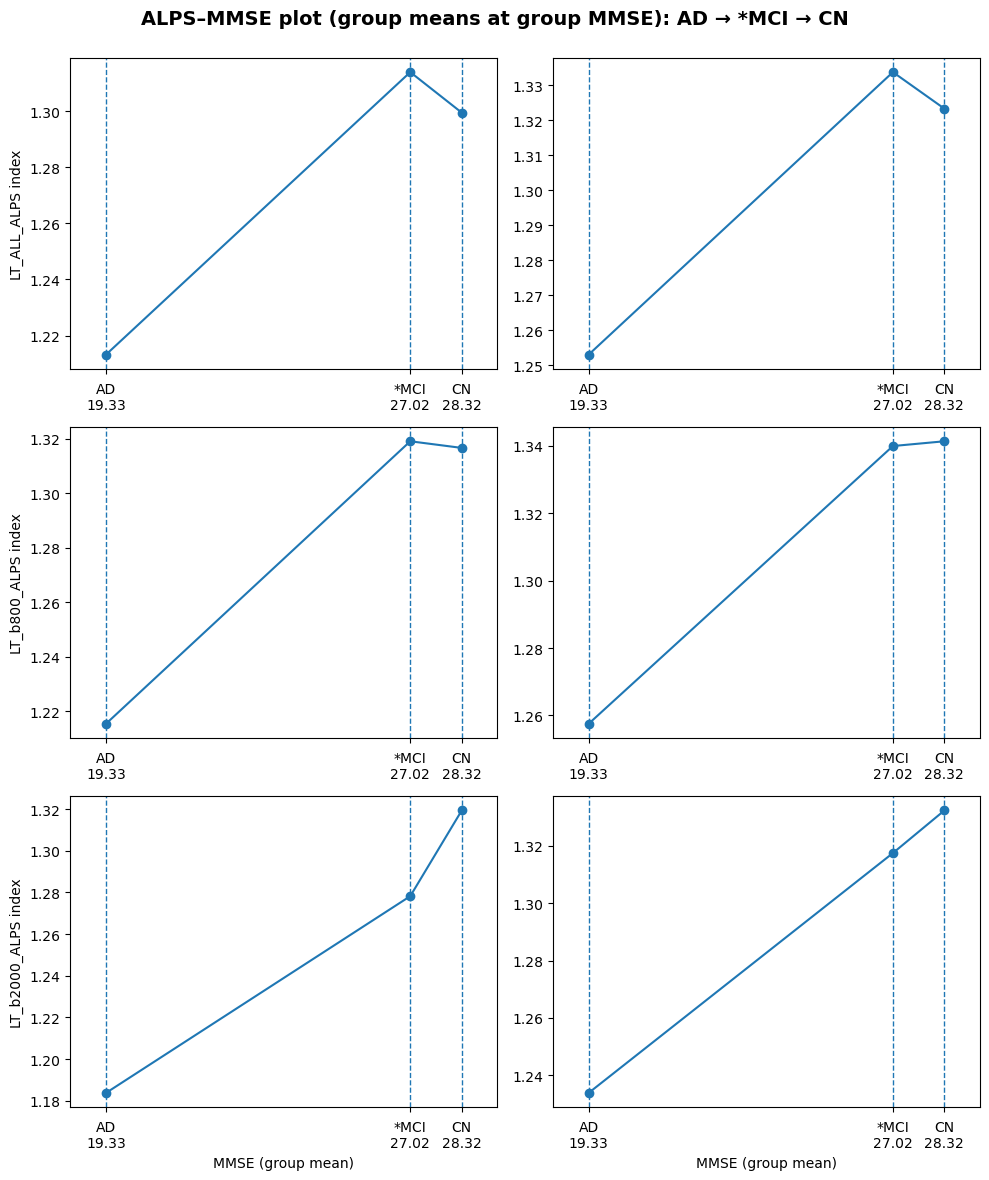

Saved: D:\JHAhn\files\ALPS_group_means_subplot.pdf


In [31]:
'''
# 1) DDX 4→3그룹 재코딩
map_ddx = {'NL':'CN', 'SaMCI':'*MCI', 'MaMCI':'*MCI', 'AD':'AD'}
dfP = dfA.copy()
dfP['DDX3'] = dfP['DDX'].map(map_ddx)

# 2) 6개 ALPS 지표(3×2)
pairs = [
    ('LT_ALL_ALPS index',   'RT_ALL_ALPS index'),
    ('LT_b800_ALPS index',  'RT_b800_ALPS index'),
    ('LT_b2000_ALPS index', 'RT_b2000_ALPS index'),
]
group_order = ['AD', '*MCI', 'CN']

fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharex=False)
for r, (yl, yr) in enumerate(pairs):
    for c, y in enumerate((yl, yr)):
        ax = axes[r, c]
        if y not in dfP.columns:
            ax.axis('off')
            continue

        # 해당 지표의 유효 데이터로 서브셋 구성
        sub = dfP[['MMSE', y, 'DDX3']].copy()
        sub['MMSE'] = pd.to_numeric(sub['MMSE'], errors='coerce')
        sub[y]      = pd.to_numeric(sub[y],      errors='coerce')
        sub = sub.dropna()
        if sub.empty:
            ax.axis('off')
            continue

        grp = sub.groupby('DDX3')
        # x: 그룹별 MMSE 평균 위치, y: 지표 평균
        mmse_pos = grp['MMSE'].mean().reindex(group_order).dropna()
        y_mean   = grp[y].mean().reindex(mmse_pos.index)

        ax.plot(mmse_pos.values, y_mean.values, marker='o')

        # 세로 가이드 & x축 눈금/라벨(그룹명)
        for gx in mmse_pos.values:
            ax.axvline(gx, linestyle='--', linewidth=1)
        labels = [f"{g}\n{m:.2f}" for g, m in zip(mmse_pos.index, mmse_pos.values)]
        ax.set_xticks(mmse_pos.values)
        ax.set_xticklabels(labels)
        ax.tick_params(axis='x', pad=6)

        # 가독성 위해 x축 범위 여유
        xmin, xmax = float(mmse_pos.min()), float(mmse_pos.max())
        span = xmax - xmin if np.isfinite(xmax - xmin) and (xmax - xmin) > 0 else 1.0
        ax.set_xlim(xmin - 0.1*span, xmax + 0.1*span)

        ax.set_ylabel(y if c == 0 else "")

axes[-1, 0].set_xlabel('MMSE (group mean)')
axes[-1, 1].set_xlabel('MMSE (group mean)')
fig.suptitle('ALPS–MMSE plot (group means at group MMSE): AD → *MCI → CN'
             , y=0.98, weight='bold', size=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# 4) PDF 저장 (show 전에 저장)
pdf_path = os.path.join(out, 'ALPS_group_means_subplot.pdf')
fig.savefig(pdf_path)
plt.close(fig)
print(f'Saved: {pdf_path}')
'''

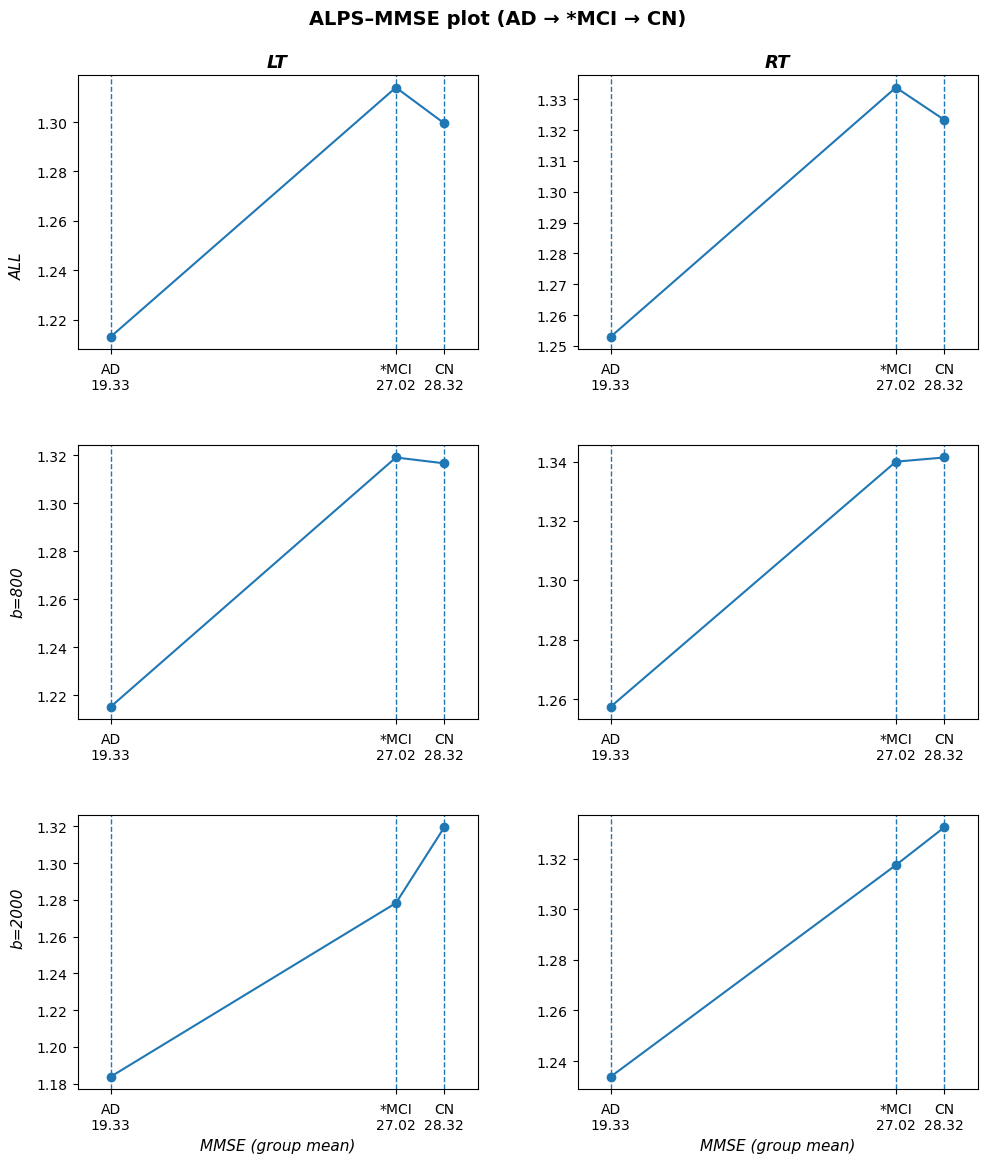

Saved: D:\JHAhn\files\ALPS_group_means_subplot.pdf


In [45]:
# 1) DDX 4→3그룹 재코딩
map_ddx = {'NL':'CN', 'SaMCI':'*MCI', 'MaMCI':'*MCI', 'AD':'AD'}
dfP = dfA.copy()
dfP['DDX3'] = dfP['DDX'].map(map_ddx)

# 2) 6개 ALPS 지표(3×2)
pairs = [
    ('LT_ALL_ALPS index',   'RT_ALL_ALPS index'),
    ('LT_b800_ALPS index',  'RT_b800_ALPS index'),
    ('LT_b2000_ALPS index', 'RT_b2000_ALPS index'),
]
group_order = ['AD', '*MCI', 'CN']
row_labels   = ['ALL', 'b=800', 'b=2000']  # ← 세로로 표시할 행 라벨

# 3) 그리기 (sharex=False: 각 지표별 MMSE 평균 위치가 다를 수 있음)
fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharex=False)

for r, (yl, yr) in enumerate(pairs):
    for c, y in enumerate((yl, yr)):
        ax = axes[r, c]
        if y not in dfP.columns:
            ax.axis('off'); continue

        sub = dfP[['MMSE', y, 'DDX3']].apply(pd.to_numeric, errors='coerce')
        sub['DDX3'] = dfP['DDX3']
        sub = sub.dropna()
        if sub.empty:
            ax.axis('off'); continue

        grp      = sub.groupby('DDX3')
        mmse_pos = grp['MMSE'].mean().reindex(group_order).dropna()   # x: 그룹별 MMSE 평균
        y_mean   = grp[y].mean().reindex(mmse_pos.index)              # y: 지표 그룹 평균

        ax.plot(mmse_pos.values, y_mean.values, marker='o')
        for gx in mmse_pos.values:
            ax.axvline(gx, linestyle='--', linewidth=1)

        # x축 라벨: "{Group}\n{mean:.2f}"
        labels = [f"{g}\n{m:.2f}" for g, m in zip(mmse_pos.index, mmse_pos.values)]
        ax.set_xticks(mmse_pos.values)
        ax.set_xticklabels(labels)
        ax.tick_params(axis='x', pad=6)

        # 좌우 여백 조금
        xmin, xmax = float(mmse_pos.min()), float(mmse_pos.max())
        span = xmax - xmin if xmax > xmin else 1.0
        ax.set_xlim(xmin - 0.10*span, xmax + 0.10*span)

        # 모든 y라벨 제거(→ 오른쪽 밀림 방지)
        ax.set_ylabel('')

# ── 행 라벨을 그림 여백에 '세로로' 추가 (축 배치에 영향 없음) ──
for r, lab in enumerate(row_labels):
    pos = axes[r, 0].get_position()
    yc  = (pos.y0 + pos.y1) / 2.0
    fig.text(0.02, yc, lab, rotation=90, va='center', ha='center', fontstyle='italic', fontsize=11)

# 열 제목: 맨 위에만 LT / RT
axes[0, 0].set_title('LT', fontweight='bold', fontstyle='italic', fontsize=13)
axes[0, 1].set_title('RT', fontweight='bold', fontstyle='italic', fontsize=13)

axes[-1, 0].set_xlabel('MMSE (group mean)', fontstyle='italic', fontsize=11)
axes[-1, 1].set_xlabel('MMSE (group mean)', fontstyle='italic', fontsize=11)

fig.suptitle('ALPS–MMSE plot (AD → *MCI → CN)', fontsize=14, fontweight='bold', y=0.98)

# 레이아웃(왼쪽 여백 약간 늘리고 전체 균형 조정)
fig.subplots_adjust(left=0.08, right=0.98, top=0.925, bottom=0.08, hspace=0.35, wspace=0.25)


# 4) PDF 저장 (show 전에 저장)
fig.savefig(os.path.join(out, 'ALPS_group_means_subplot.pdf'))
plt.show()
plt.close(fig)
print(f'Saved: {pdf_path}')

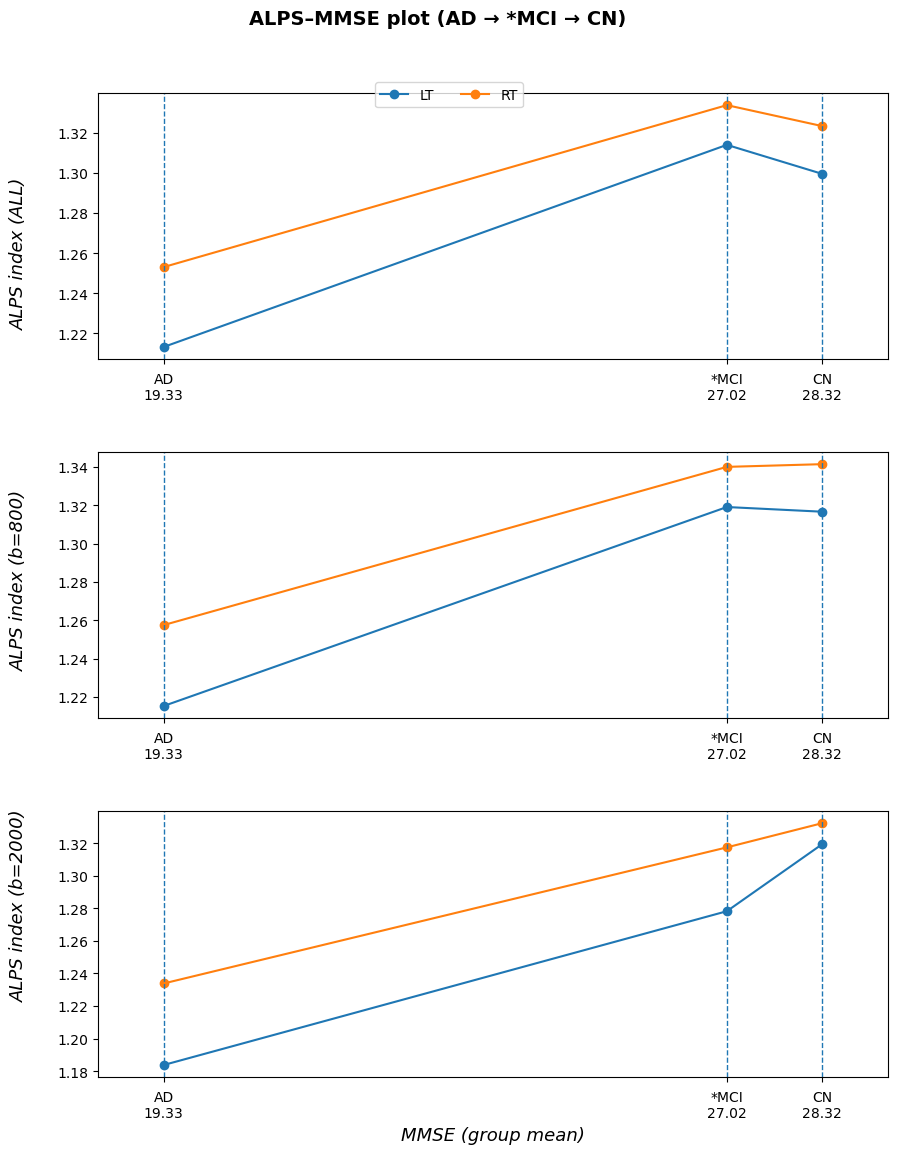

Saved: D:\JHAhn\files\ALPS_group_means_subplot_M01.pdf


In [83]:
map_ddx = {'NL':'CN', 'SaMCI':'*MCI', 'MaMCI':'*MCI', 'AD':'AD'}
dfP = dfA.copy()
dfP['DDX3'] = dfP['DDX'].map(map_ddx)

# 2) 6개 ALPS 지표를 3행(ALL, b800, b2000)으로 묶기: (LT, RT)
rows = [
    ('LT_ALL_ALPS index',   'RT_ALL_ALPS index'),
    ('LT_b800_ALPS index',  'RT_b800_ALPS index'),
    ('LT_b2000_ALPS index', 'RT_b2000_ALPS index'),
]
row_labels = ['ALPS index (ALL)', 'ALPS index (b=800)', 'ALPS index (b=2000)']
group_order = ['AD', '*MCI', 'CN']

# 3) 3×1 서브플롯
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

legend_handles = None  # 하단 공통 legend용 핸들 캐치

for r, (yL, yR) in enumerate(rows):
    ax = axes[r]
    # 해당 행에서 필요한 칼럼만
    cols_need = ['MMSE', yL, yR, 'DDX3']
    if not set(cols_need).issubset(dfP.columns):
        ax.axis('off')
        continue

    sub = dfP[cols_need].copy()
    sub['MMSE'] = pd.to_numeric(sub['MMSE'], errors='coerce')
    sub[yL]     = pd.to_numeric(sub[yL],     errors='coerce')
    sub[yR]     = pd.to_numeric(sub[yR],     errors='coerce')
    sub = sub.dropna()  # MMSE, yL, yR 모두 있는 공통 서브셋

    if sub.empty:
        ax.axis('off')
        continue

    grp = sub.groupby('DDX3')

    # x: 공통 서브셋에서의 그룹별 MMSE 평균 (AD → *MCI → CN 순)
    mmse_pos = grp['MMSE'].mean().reindex(group_order).dropna()

    # y: LT/RT 각각의 그룹 평균 (동일 인덱스 순서로 정렬)
    yL_mean = grp[yL].mean().reindex(mmse_pos.index)
    yR_mean = grp[yR].mean().reindex(mmse_pos.index)

    # 선+점(색상은 Matplotlib 기본 사이클로 다르게 됨)
    lineL, = ax.plot(mmse_pos.values, yL_mean.values, marker='o', label='LT')
    lineR, = ax.plot(mmse_pos.values, yR_mean.values, marker='o', label='RT')

    # 공통 legend를 위해 한 번만 핸들 보관
    if legend_handles is None:
        legend_handles = (lineL, lineR)

    # 세로 가이드
    for gx in mmse_pos.values:
        ax.axvline(gx, linestyle='--', linewidth=1)

    # x축 라벨: "{Group}\n{mean:.2f}"
    labels = [f"{g}\n{m:.2f}" for g, m in zip(mmse_pos.index, mmse_pos.values)]
    ax.set_xticks(mmse_pos.values)
    ax.set_xticklabels(labels)
    ax.tick_params(axis='x', pad=6)

    # 좌우 여유
    xmin, xmax = float(mmse_pos.min()), float(mmse_pos.max())
    span = xmax - xmin if xmax > xmin else 1.0
    ax.set_xlim(xmin - 0.10*span, xmax + 0.10*span)

    # 개별 y라벨 제거(왼쪽 여백 밀림 방지)
    ax.set_ylabel('')

# ── 세로 행 라벨을 여백에 표시 ──
for r, lab in enumerate(row_labels):
    pos = axes[r].get_position()    # Bbox (figure 좌표계)
    x   = pos.x0 - 0.035            # 왼쪽으로 조금 띄우기 (간격 조정은 이 값 변경)
    yc  = (pos.y0 + pos.y1) / 2.0
    fig.text(x, yc, lab, rotation=90, va='center', ha='right', fontsize=13, fontstyle='italic')

# 하단 공통 legend
if legend_handles is not None:
    fig.legend(legend_handles, ['LT', 'RT'],
               loc='upper center', ncol=2, frameon=True, borderaxespad=6)

# 하단 x라벨(맨 아래 축만)
axes[-1].set_xlabel('MMSE (group mean)', fontsize=13, fontstyle='italic')

# 제목 및 레이아웃
fig.suptitle('ALPS–MMSE plot (AD → *MCI → CN)', fontsize=14, fontweight='bold', y=0.97)
# 하단 legend 공간 확보 위해 bottom 늘림
fig.subplots_adjust(left=0.16, right=0.95, top=0.90, bottom=0.08, hspace=0.35)
plt.show()

# 4) PDF 저장
pdf_path = os.path.join(out, 'ALPS_group_means_subplot_M01.pdf')
fig.savefig(pdf_path)
plt.close(fig)
print(f"Saved: {pdf_path}")